In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(12,6)

In [5]:
import pandas as pd

# Load cleaned datasets
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

# Load benchmark dataset
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [6]:
print(nav.columns)
print(performance.columns)
print(benchmark.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')


In [7]:
import pandas as pd

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily return
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head())

# Distribution
nav["daily_return"].describe()

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

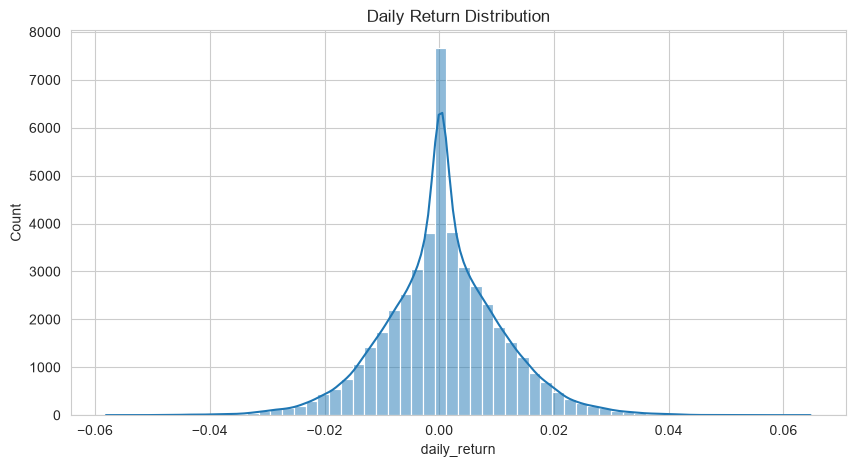

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=60,
    kde=True
)

plt.title("Daily Return Distribution")

plt.savefig("../charts/daily_return_distribution.png")

plt.show()

In [9]:
cagr = performance[
    [
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
]

display(cagr)

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43
5,HDFC Top 100 Fund - Regular Plan - Growth,10.94,14.84,11.32
6,HDFC Top 100 Fund - Direct Plan - Growth,11.48,13.38,13.48
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,19.98,15.29,15.85
9,HDFC Short Term Debt Fund - Regular - Growth,6.83,7.37,6.41


In [11]:
sharpe = performance[
    [
        "scheme_name",
        "sharpe_ratio"
    ]
].sort_values(
    "sharpe_ratio",
    ascending=False
)

display(sharpe.head(10))

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [12]:
sortino = performance[
    [
        "scheme_name",
        "sortino_ratio"
    ]
].sort_values(
    "sortino_ratio",
    ascending=False
)

display(sortino.head(10))

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


In [13]:
alpha_beta = performance[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.to_csv(
    "../alpha_beta.csv",
    index=False
)

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [14]:
drawdown = performance[
    [
        "scheme_name",
        "max_drawdown_pct"
    ]
].sort_values(
    "max_drawdown_pct"
)

drawdown.head(10)

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


In [15]:
performance["return_rank"] = performance["return_3yr_pct"].rank(ascending=False)
performance["sharpe_rank"] = performance["sharpe_ratio"].rank(ascending=False)
performance["alpha_rank"] = performance["alpha"].rank(ascending=False)
performance["expense_rank"] = performance["expense_ratio_pct"].rank(ascending=True)
performance["drawdown_rank"] = performance["max_drawdown_pct"].rank(ascending=True)

performance["score"] = (
    0.30 * performance["return_rank"] +
    0.25 * performance["sharpe_rank"] +
    0.20 * performance["alpha_rank"] +
    0.15 * performance["expense_rank"] +
    0.10 * performance["drawdown_rank"]
)

scorecard = performance[
    [
        "scheme_name",
        "score"
    ]
].sort_values(
    "score"
)

scorecard.to_csv(
    "../fund_scorecard.csv",
    index=False
)

scorecard.head(10)

,scheme_name,score
3,SBI Small Cap Fund - Direct Plan - Growth,11.900
22,Kotak Flexicap Fund - Regular - Growth,12.400
21,Kotak Emerging Equity Fund - Regular - Growth,12.800
29,ABSL Small Cap Fund - Regular - Growth,13.700
2,SBI Small Cap Fund - Regular Plan - Growth,15.250
34,Mirae Asset Large Cap Fund - Regular - Growth,15.425
9,HDFC Short Term Debt Fund - Regular - Growth,15.800
14,ICICI Pru Liquid Fund - Regular - Growth,16.300
12,ICICI Pru Midcap Fund - Regular - Growth,16.600
11,ICICI Pru Bluechip Fund - Direct - Growth,17.150


In [16]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 funds by 3-year return
top5 = performance.sort_values(
    "return_3yr_pct",
    ascending=False
).head(5)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top5,
    x="scheme_name",
    y="return_3yr_pct"
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("3-Year Return (%)")
plt.xlabel("Fund")
plt.title("Top 5 Funds by 3-Year Return")

plt.tight_layout()

plt.savefig("../charts/top5_funds_return.png")

plt.show()

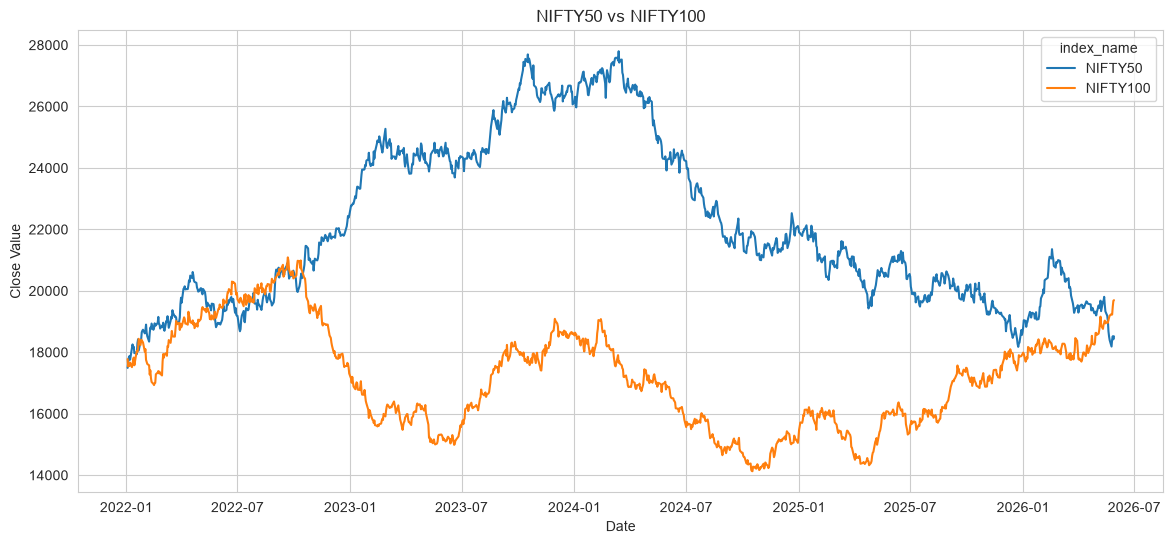

In [17]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

compare = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=compare,
    x="date",
    y="close_value",
    hue="index_name"
)

plt.title("NIFTY50 vs NIFTY100")

plt.xlabel("Date")
plt.ylabel("Close Value")

plt.grid(True)

plt.savefig("../charts/nifty_comparison.png")

plt.show()

In [18]:
pivot = compare.pivot(
    index="date",
    columns="index_name",
    values="close_value"
)

pivot["tracking_error"] = (
    pivot["NIFTY100"] - pivot["NIFTY50"]
)

print("Approximate Tracking Error")
print(pivot["tracking_error"].std())

Approximate Tracking Error
3345.0134424691187


In [19]:
scorecard.to_csv("../fund_scorecard.csv", index=False)
alpha_beta.to_csv("../alpha_beta.csv", index=False)